In [38]:
import networkx as nx
import networkit as nk
import rustworkx as rx
import igraph as ig

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.animation import FuncAnimation
import itertools as it
from tqdm import tqdm
import logging
from collections import OrderedDict
import operator
import shapely
from shapely.geometry import LineString, Point
import shapely.geometry
from shapely.ops import linemerge
import pandas as pd
import copy



import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from main_helpers import timeit, Base_car_fleet, Car, Display, UnitTest, select_min_weight_lane
from attack.attack import feature_based_attack

np.random.seed(1)

ox.__version__

'2.1.0'

### Initial state

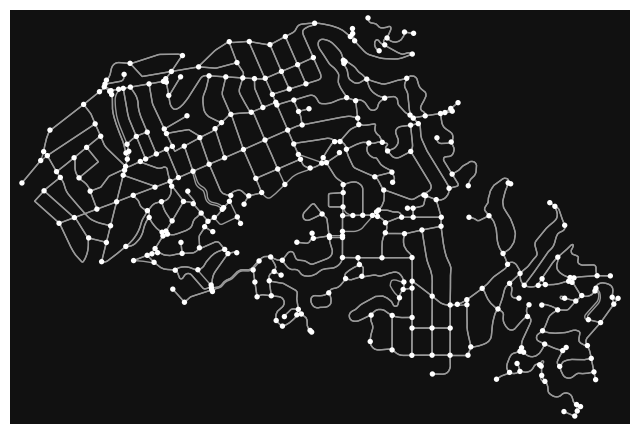

In [39]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Escaudes, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

### Preprocessing

In [40]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'load': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'load': 0, 'weight': 1, 'capacity': 8}


In [41]:
for u,v,k in G.edges:
    if 'geometry' not in G.edges[u,v,k]:
        G[u][v][k]['geometry']=LineString([[G.nodes[u]['x'], G.nodes[u]['y']], [G.nodes[v]['x'], G.nodes[v]['y']]])

In [42]:
# G3=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
# G3=nx.DiGraph(G)
G3=G

In [43]:
len(max(list(nx.strongly_connected_components(G3)), key=len))/G3.number_of_nodes()

0.9914772727272727

In [44]:
# Get strongly connected component
G4 = max(list(nx.strongly_connected_components(G3)), key=len)
G4 = G3.subgraph(G4)

In [45]:
G4_proj=ox.project_graph(G4)

### Bla

In [ ]:
class Car_fleet(Base_car_fleet):

    def move(self, car:Car, time_step=20):
        time_remaining = time_step
        speed = 50 / 3.6
        
        while time_remaining > 0 and not car.completed and car.next_true_node:
            edge=self.rx_helper.nx_graph[car.last_true_node][car.next_true_node][car.next_edge_key]
            geom:LineString=edge['geometry']
            dist_from_start = geom.project(car.loc)
            dist_to_go = speed * time_remaining
            new_dist = dist_from_start + dist_to_go
            
            if new_dist > geom.length:
                # On termine l'arête actuelle
                dist_covered = geom.length - dist_from_start
                time_used = dist_covered / speed
                time_remaining -= time_used
                
                # Passage au nœud suivant
                if car.last_true_node!=car.dep:
                    self.handle_interactions(car.last_true_node, car.next_true_node, car.next_edge_key, -1, 1, op=operator.lt) # Update old edges
                car.go_to_next_true_node(self.rx_helper.nx_graph, edge['weight'])
                if not car.completed and car.next_true_node: #Voiture pas arrivée ou sait pas où aller
                    car.next_edge_key, _ = select_min_weight_lane(self.rx_helper.nx_graph, car.last_true_node, car.next_true_node, 'weight')
                    self.handle_interactions(car.last_true_node, car.next_true_node, car.next_edge_key, 1, 10000, op=operator.ge) # Update new edges
                    # La boucle continue avec le temps restant
                else:
                    break
            else:
                # On reste sur la même arête
                car.loc = geom.interpolate(new_dist)
                time_remaining = 0 # On a fini de bouger pour ce step
                
        return car.loc

    @timeit
    def update_fleet(self, time_step):
        """
    Updates car states and handles interactions during displacement.
        """
        for k,car in enumerate(self.fleet):
            if not car.completed:
                # On recalcule pas le chemin à un pas de l'arrivée si on sait où on va
                if car.next_true_node!=car.arr:
                    if car.next_true_node:
                        path = copy.deepcopy(self.all_paths[car.next_true_node][car.arr][0])
                    else: #Voit sait pas où aller -> bloquée à une intersection
                        # On choppe le chemin calculé depuis cette intersection et pas la suivante
                        path = copy.deepcopy(self.all_paths[car.last_true_node][car.arr][0])
                        if len(path)>1: #Si la route est toujours bloquée le path est vide
                            path.pop(0)
                            car.next_true_node=path[0]
                    car.path=path
                    cost = self.get_cost(path, 'weight')
                    car.cost=cost
                    if cost>1000:
                        self.info.append((car.last_true_node, car.next_true_node))

                # Si la route est pas bloquée
                if self.rx_helper.nx_graph.has_edge(car.last_true_node, car.next_true_node, car.next_edge_key):
                    point=self.move(car, time_step)

                    if k<self.log_trajs:
                        car.traj.append(point)
                # On supprime pas l'ancien état puisque deux voitures peuvent se suivre
                self.edges_state[(car.next_true_node, car.arr)]=self.check_edges_along_path(car.path)
            elif car.completed and car.last_true_node!=car.next_true_node: #Vient juste d'arriver
                car.last_true_node=car.next_true_node

    def run(self, attack=True, repair=True, time_step=20):
        self.info=[]
        if not self.all_completed():
            if attack :
                self.launch_attack()
            if repair :
                self.repair_attack()
            all_paths=self.calculate_paths(dist=3)
            self.update_fleet(time_step)
            self.step+=1


### Dynamique induite et update

100%|██████████| 90/90 [00:07<00:00, 28.85it/s]

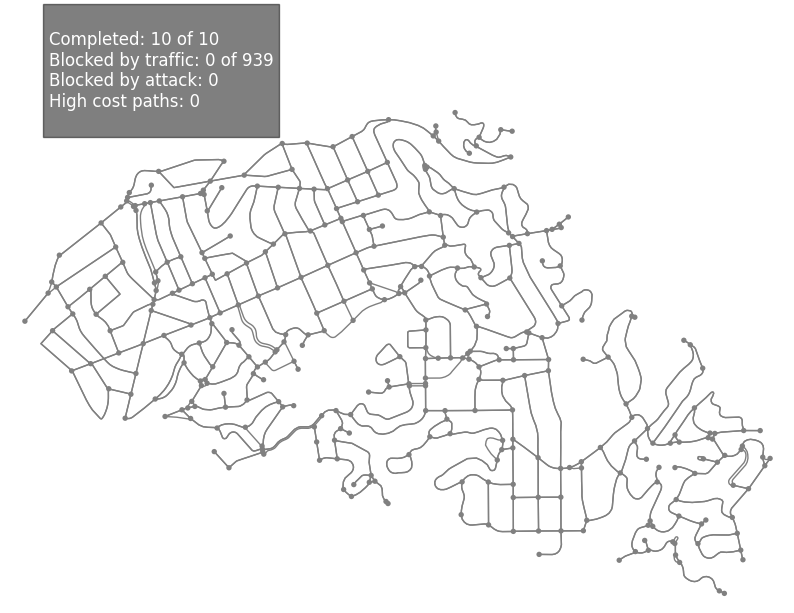

91it [00:11,  7.79it/s]                        


In [54]:
demand=Car_fleet(G4_proj.copy(), size=10, log_trajs=10)
demand.prepare_attack(attack='deg', batch_size=5, number_steps=30)
frames=90
logging.info(f'__________________________________________________________________')

def update(frame):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.run(attack=True, repair=True, time_step=20)
    # demand.display_h.display_huge(demand, ax=ax)
    demand.display_h.display(demand, ax=ax)
    # demand.display_h.display_graph(demand.rx_helper.nx_graph, demand)
    string=f'''
Completed: {sum(demand.get_completed())} of {demand.num_cars}
Blocked by traffic: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}
Blocked by attack: {len(list(it.chain.from_iterable(demand.rmvd_edges)))}
High cost paths: {len(demand.info)}
'''
    ax.text(0.05, 0.95, string,
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow', 
            #  progress_callback = lambda i, n: print(f'Saving frame {i}/{n}', end='\r')
             )
    plt.show()
UnitTest(demand).run()

In [48]:
import folium

class DisplayCustom(Display):
    def display_graph(self, graph, demand=None, show=True):
        nodes, edges = ox.convert.graph_to_gdfs(graph)
        if demand:
            edges['color']=self.get_edge_c(demand.rx_helper.nx_graph)
        m = edges.explore(
            tiles="cartodbdarkmatter",
            color='color' if demand else None
        )
        map=nodes.explore(
            m=m, 
            marker_kwds={"radius": 3}
        )
        if demand and demand.log_trajs:
            for k,(car,color) in enumerate(zip(demand.fleet, self.colors)):
                for point in car.traj:
                    point_geom_proj, crs = (
                        ox.projection.project_geometry(
                            point, 
                            crs=demand.graph.graph['crs'], 
                            to_latlong=True
                            )
                    )

                    folium.Marker(
                        location=[point_geom_proj.y, point_geom_proj.x],
                        tooltip=f"{car.arr}",
                        popup=car.__repr__(),
                        icon=folium.Icon(color=color,icon=f"{k}", prefix='fa'),
                    ).add_to(map)
        if show:
            self.show_folium_safe(map)
        return map

In [49]:
dis=DisplayCustom()
nodes, edges = ox.convert.graph_to_gdfs(demand.rx_helper.nx_graph)
edges['color']=dis.get_edge_c(demand.rx_helper.nx_graph)
# edges

In [ ]:
# explore nodes and edges together in a single map
dis=DisplayCustom()
demand_display=copy.deepcopy(demand)
demand_display.fleet=demand_display.fleet[:demand.log_trajs]
map=dis.display_graph(demand.rx_helper.nx_graph, demand_display, True)
# map=dis.display_graph(demand.graph, None, True)
# map.save('file.html')

In [51]:
demand.get_completed()

[np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,

In [52]:
demand.fleet[5]

((53075602,53156415), None, None, -1)